# Notebook 02 — Feature Engineering & Labels

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Phase :** 3 — Feature engineering et préparation des données supervisées  
**Objectif :** Explorer les features calculées et les labels de supervision.

## Pipeline features
```
data/raw/episode=XXX/          (données brutes — Notebook 01)
    └─► features/pipeline.py
        ├─► temporal.py        → deltas, rolling stats, margin
        ├─► contextual.py      → hot_zone, shutdowns, recovering
        ├─► energy.py          → PUE, power_fans, fan_energy_ratio
        └─► labeler.py         → failure_30s, failure_60s, action_class
            └─► data/processed/episode=XXX/features.parquet
```

## Groupes de features (47 features utilisées pour la modélisation)
| Groupe | Exemples | Rôle |
|--------|---------|------|
| Temporelles | `temp_delta_30s`, `margin_to_shutdown`, `rpm_rolling_mean_30s` | Dynamique thermique |
| Contextuelles | `time_in_hot_zone_s`, `nb_shutdowns_episode`, `is_recovering` | Historique machine |
| Energétiques | `pue_estimated`, `power_fans_w`, `fan_energy_ratio` | Consommation |

## Labels de supervision
| Label | Description | Utilisation |
|-------|-------------|-------------|
| `failure_30s` | Panne dans les 30s | Prédiction court-terme |
| `failure_60s` | Panne dans les 60s | Prédiction moyen-terme (Phase 4) |
| `hot_30s` | Température critique dans 30s | Alerte thermique |
| `action_class` | RPM optimal {0,1,2,3,4} → {0,1500,2500,3500,4500} | Contrôleur supervisé (Phase 5) |

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'features').exists() and (_candidate / 'data').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

PROC_DIR = Path('data/processed')
episodes = sorted(p for p in PROC_DIR.glob('episode=*') if p.is_dir())
print(f'Repertoire : {Path.cwd()}')
print(f'Episodes processed : {[p.name for p in episodes]}')

Repertoire : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs
Episodes processed : ['episode=001', 'episode=002', 'episode=003', 'episode=004', 'episode=005', 'episode=006', 'episode=data']


## 1. Schéma des features calculées

In [2]:
df = pd.read_parquet(episodes[0] / 'features.parquet')
print(f'Shape (episode=001) : {df.shape}')
print(f'Machines : {df["machine_id"].unique().tolist()}')
print()

# Groupes de features
FEATURE_GROUPS = {
    'Brutes (raw)': ['temperature_c','sensor_temp_max','sensor_temp_mean',
                     'power_w','energy_kwh','fan_rpm_mean','load_estimated'],
    'Temporelles': ['temp_delta_5s','temp_delta_30s','temp_rolling_mean_30s',
                    'temp_rolling_mean_60s','temp_rolling_std_30s',
                    'margin_to_shutdown','margin_pct','margin_delta_30s',
                    'rpm_rolling_mean_30s','load_rolling_mean_30s'],
    'Contextuelles': ['time_in_hot_zone_s','nb_shutdowns_episode',
                      'nb_degraded_episode','ticks_since_last_shutdown',
                      'has_fan_fault','has_power_surge','is_recovering'],
    'Energetiques': ['power_fans_w','fan_energy_ratio','pue_estimated',
                     'energy_fans_kwh_cumulated','pue_rolling_mean_30s'],
    'Labels (classification)': ['failure_30s','failure_60s','hot_30s'],
    'Labels (contrôle — oracle)': ['action_class','action_class_v2','optimal_rpm','time_to_failure_s'],
}

for group, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    print(f'[{group}] ({len(present)} features)')
    for c in present:
        null_pct = df[c].isnull().mean() * 100
        print(f'  {c:<40} mean={df[c].mean():.2f}  null={null_pct:.0f}%')
    print()

print('NOTE : time_to_failure_s = NaN quand aucune panne imminente connue (oracle v2 uniquement)')


Shape (episode=001) : (35826, 70)
Machines : ['srv-master-01', 'srv-master-02', 'srv-worker-03', 'srv-worker-02', 'srv-worker-01']

[Brutes (raw)] (7 features)
  temperature_c                            mean=51.29  null=0%
  sensor_temp_max                          mean=51.29  null=0%
  sensor_temp_mean                         mean=47.89  null=0%
  power_w                                  mean=373.38  null=0%
  energy_kwh                               mean=157.73  null=0%
  fan_rpm_mean                             mean=847.70  null=0%
  load_estimated                           mean=0.18  null=0%

[Temporelles] (10 features)
  temp_delta_5s                            mean=0.00  null=0%
  temp_delta_30s                           mean=0.02  null=0%
  temp_rolling_mean_30s                    mean=51.28  null=0%
  temp_rolling_mean_60s                    mean=51.27  null=0%
  temp_rolling_std_30s                     mean=0.55  null=0%
  margin_to_shutdown                       mean=37.51  n

## 2. Distribution des labels par épisode

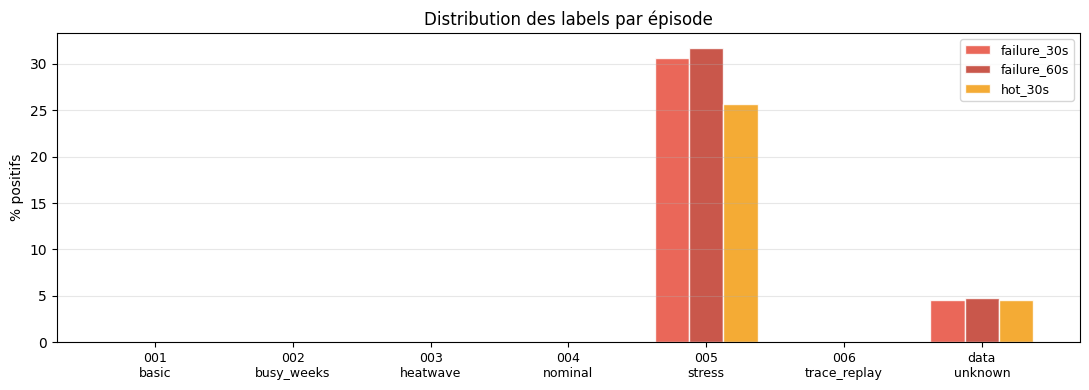

,scenario,n,failure_30s,failure_60s,hot_30s
episode,,,,,
001,basic,35826,0.0,0.0,0.0
002,busy_weeks,54873,0.0,0.0,0.0
003,heatwave,55107,0.0,0.0,0.0
004,nominal,53224,0.0,0.0,0.0
005,stress,54559,30.6,31.7,25.7
006,trace_replay,50507,0.0,0.0,0.0
data,unknown,305596,4.5,4.7,4.6


In [3]:
label_cols = ['failure_30s', 'failure_60s', 'hot_30s']
ep_labels = []
for ep in episodes:
    df_ep = pd.read_parquet(ep / 'features.parquet')
    meta_f = Path('data/raw') / ep.name / 'metadata.json'
    scenario = 'unknown'
    if meta_f.exists():
        import json
        scenario = json.loads(meta_f.read_text()).get('scenario','?')
    row = {'episode': ep.name.replace('episode=',''), 'scenario': scenario, 'n': len(df_ep)}
    for lbl in label_cols:
        if lbl in df_ep.columns:
            row[lbl] = df_ep[lbl].mean() * 100
        else:
            row[lbl] = 0.0
    ep_labels.append(row)

df_lbl = pd.DataFrame(ep_labels).set_index('episode')

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(df_lbl))
w = 0.25
colors_lbl = ['#e74c3c', '#c0392b', '#f39c12']
for i, (lbl, color) in enumerate(zip(label_cols, colors_lbl)):
    ax.bar(x + i*w, df_lbl[lbl], width=w, label=lbl, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels([f"{ep}\n{sc}" for ep, sc in zip(df_lbl.index, df_lbl['scenario'])], fontsize=9)
ax.set_ylabel('% positifs')
ax.set_title('Distribution des labels par épisode')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation/results/fig_02_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
display(df_lbl[['scenario','n'] + label_cols].round(1))

## 3. Distribution de action_class et action_class_v2

L'oracle v1 (`action_class`) utilise uniquement la température instantanée.  
L'oracle v2 (`action_class_v2`) intègre la vitesse thermique (`temp_delta_30s`) et l'urgence (`time_to_failure_s`).
Depuis la Phase 7.5, le plancher est **800 RPM** (plus de RPM=0).


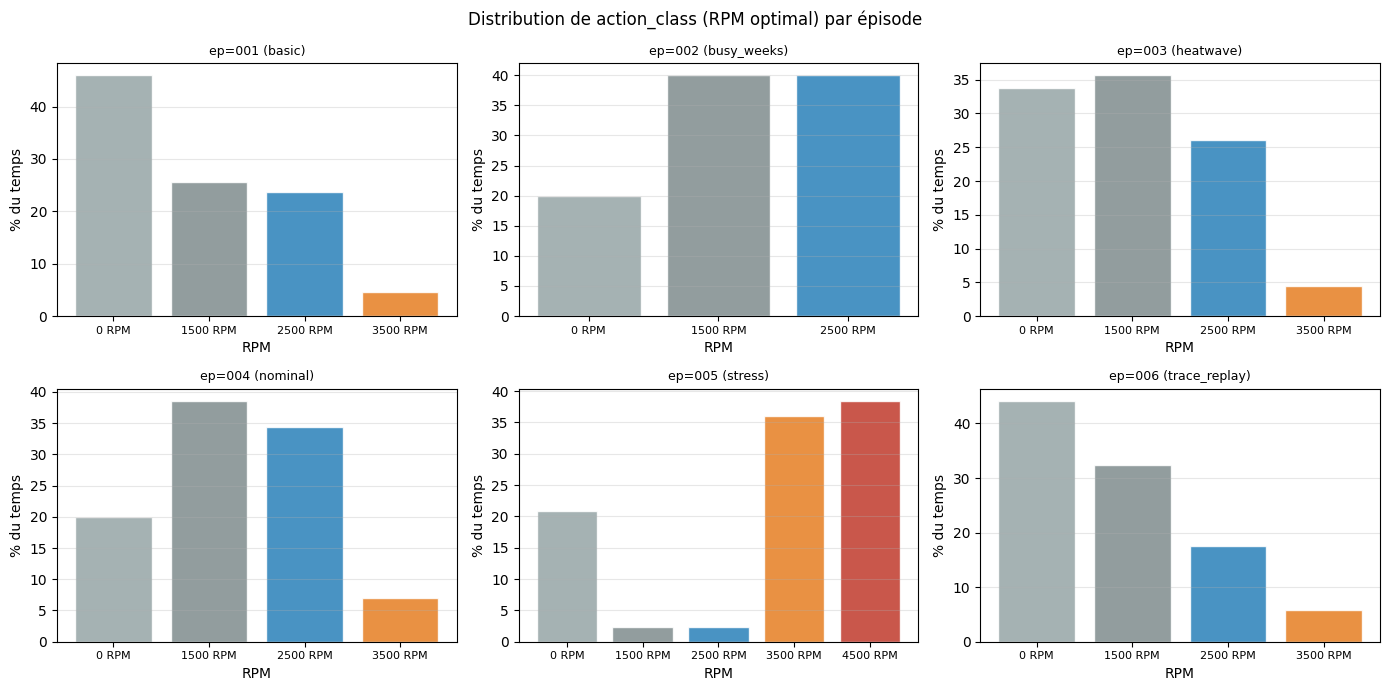

In [4]:
# Mapping classe → RPM (Phase 7.5 : plancher 800 RPM, plus de 0)
action_to_rpm = {0: 800, 1: 1500, 2: 2500, 3: 3500, 4: 4500}
colors_rpm = ['#7f8c8d', '#2980b9', '#27ae60', '#e67e22', '#c0392b']

fig, axes = plt.subplots(2, len(episodes), figsize=(3 * len(episodes), 9))
if len(episodes) == 1:
    axes = axes.reshape(2, 1)

for col_idx, ep in enumerate(episodes):
    df_ep = pd.read_parquet(ep / 'features.parquet')
    meta_f = Path('data/raw') / ep.name / 'metadata.json'
    scenario = 'unknown'
    if meta_f.exists():
        import json
        scenario = json.loads(meta_f.read_text()).get('scenario', '?')
    ep_name = ep.name.replace('episode=', '')

    # Ligne 1 : action_class (oracle v1)
    ax1 = axes[0, col_idx]
    if 'action_class' in df_ep.columns:
        counts = df_ep['action_class'].value_counts().sort_index()
        labels = [f'{action_to_rpm.get(int(k), k)} RPM' for k in counts.index]
        ax1.bar(labels, counts.values / len(df_ep) * 100,
                color=[colors_rpm[int(k)] for k in counts.index], alpha=0.85, edgecolor='white')
        ax1.set_title(f'ep={ep_name} ({scenario})', fontsize=9)
        ax1.set_ylabel('% du temps')
        ax1.set_xlabel('RPM (oracle v1)')
        ax1.grid(axis='y', alpha=0.3)
        ax1.tick_params(axis='x', labelsize=8)
    else:
        ax1.set_visible(False)

    # Ligne 2 : action_class_v2 (oracle v2)
    ax2 = axes[1, col_idx]
    if 'action_class_v2' in df_ep.columns:
        counts2 = df_ep['action_class_v2'].value_counts().sort_index()
        labels2 = [f'{action_to_rpm.get(int(k), k)} RPM' for k in counts2.index]
        ax2.bar(labels2, counts2.values / len(df_ep) * 100,
                color=[colors_rpm[int(k)] for k in counts2.index], alpha=0.85, edgecolor='white')
        ax2.set_ylabel('% du temps')
        ax2.set_xlabel('RPM (oracle v2)')
        ax2.grid(axis='y', alpha=0.3)
        ax2.tick_params(axis='x', labelsize=8)
    else:
        ax2.text(0.5, 0.5, 'action_class_v2 absent\n(relancer features/pipeline.py)',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=9, color='gray')

axes[0, 0].set_title(f'Oracle v1 — {axes[0,0].get_title()}', fontsize=9)
plt.suptitle('Distribution des classes RPM par épisode — oracle v1 (haut) vs oracle v2 (bas)', fontsize=11)
plt.tight_layout()
plt.savefig('evaluation/results/fig_02_action_class.png', dpi=120, bbox_inches='tight')
plt.show()

# Résumé chiffré
print('\n--- Résumé action_class_v2 vs action_class ---')
for ep in episodes:
    df_ep = pd.read_parquet(ep / 'features.parquet')
    ep_name = ep.name.replace('episode=', '')
    if 'action_class' in df_ep.columns and 'action_class_v2' in df_ep.columns:
        agreement = (df_ep['action_class'] == df_ep['action_class_v2']).mean()
        v2_higher = (df_ep['action_class_v2'] > df_ep['action_class']).mean()
        print(f'  ep={ep_name}: accord={agreement:.1%}  v2>v1 (plus conservateur)={v2_higher:.1%}')


## 4. Corrélations des features avec failure_60s

Dataset complet : (609692, 71)


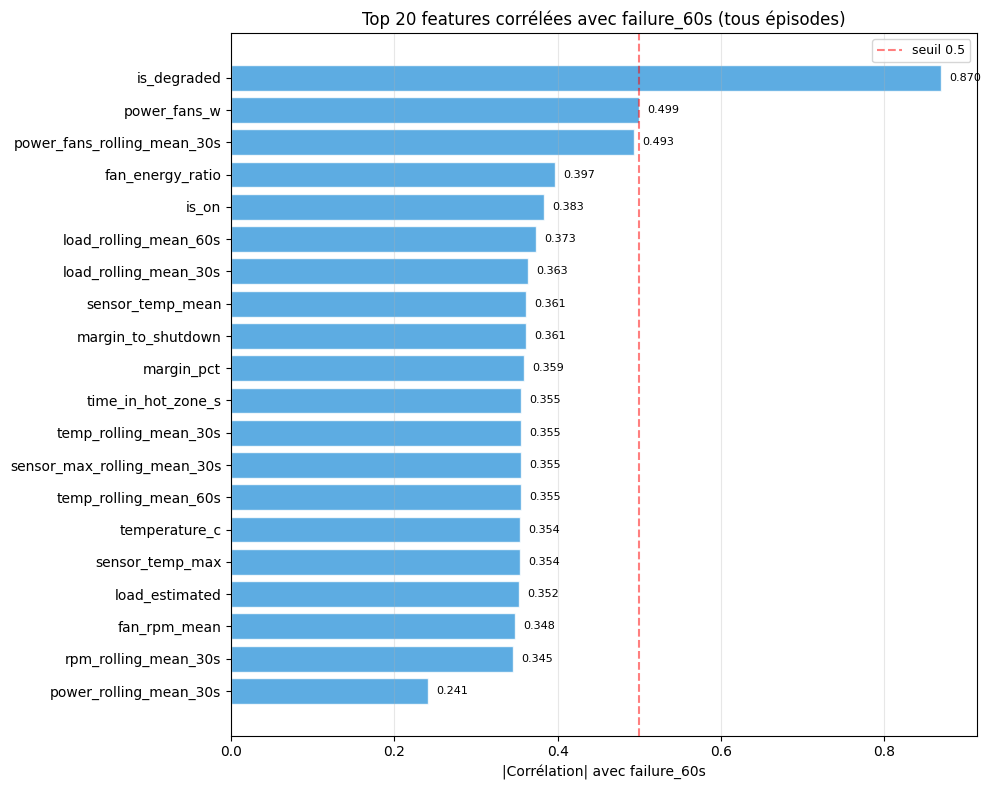

In [5]:
# Concat tous les épisodes
dfs_all = [pd.read_parquet(ep / 'features.parquet') for ep in episodes]
df_all = pd.concat(dfs_all, ignore_index=True)
print(f'Dataset complet : {df_all.shape}')

# Features numériques (hors labels et ids)
exclude = {'timestamp','cluster_id','machine_id','role','msg_type','status',
           'fan_modes','fault_types','failure_30s','failure_60s','hot_30s',
           'action_class','action_class_v2','optimal_rpm','time_to_failure_s','time_in_degraded_s'}
num_cols = [c for c in df_all.select_dtypes(include='number').columns if c not in exclude]

corr = df_all[num_cols + ['failure_60s']].corr()['failure_60s'].drop('failure_60s').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = corr.head(20)
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='#3498db', alpha=0.8, edgecolor='white')
ax.set_xlabel('|Corrélation| avec failure_60s')
ax.set_title('Top 20 features corrélées avec failure_60s (tous épisodes)')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='seuil 0.5')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('evaluation/results/fig_02_feature_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Split temporel — stratégie Option A

In [6]:
from models.failure_prediction.splitter import TemporalSplitter

splitter = TemporalSplitter()
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(label_col='failure_60s')

print('Split Option A (70 / 15 / 15 par épisode)')
print(f'  X_train : {X_train.shape}  positifs={y_train.mean():.1%}')
print(f'  X_val   : {X_val.shape}  positifs={y_val.mean():.1%}')
print(f'  X_test  : {X_test.shape}  positifs={y_test.mean():.1%}')
print(f'  Features: {X_train.shape[1]}')
print()
print('Features utilisées (47) :')
print(list(X_train.columns))

# Vérification : pas de fuite temporelle
print()
print('Vérification anti-fuite : les features ne contiennent pas les labels')
label_leaks = [c for c in X_train.columns if 'failure' in c or c == 'action_class']
print(f'  Colonnes suspectes dans X_train : {label_leaks or "aucune"}')
# Vérification présence oracle v2
print()
v2_cols = [c for c in X_train.columns if 'v2' in c or 'time_to_failure' in c]
print(f'Colonnes oracle v2 dans X_train : {v2_cols or "aucune — relancer features/pipeline.py"}')


Split Option A (70 / 15 / 15 par épisode)
  X_train : (212864, 51)  positifs=5.8%
  X_val   : (45611, 51)  positifs=5.5%
  X_test  : (45621, 51)  positifs=5.6%
  Features: 51

Features utilisées (47) :
['energy_fans_kwh_cumulated', 'energy_kwh', 'energy_per_temp_unit', 'fan_energy_ratio', 'fan_mode_manual', 'fan_rpm_mean', 'fan_rpm_std', 'has_fan_fault', 'has_power_surge', 'has_sensor_drift', 'is_degraded', 'is_off', 'is_on', 'is_recovering', 'load_estimated', 'load_rolling_mean_30s', 'load_rolling_mean_60s', 'margin_delta_30s', 'margin_pct', 'margin_to_shutdown', 'nb_degraded_episode', 'nb_shutdowns_episode', 'power_compute_w', 'power_delta_30s', 'power_fans_rolling_mean_30s', 'power_fans_w', 'power_rolling_mean_30s', 'power_w', 'pue_estimated', 'pue_rolling_mean_30s', 'rpm_changes_last_60s', 'rpm_cv', 'rpm_delta_15s', 'rpm_rolling_mean_30s', 'rpm_variance', 'sensor_max_delta_15s', 'sensor_max_rolling_mean_30s', 'sensor_temp_max', 'sensor_temp_mean', 'temp_delta_15s', 'temp_delta_30s'

## 6. Distributions des features clés

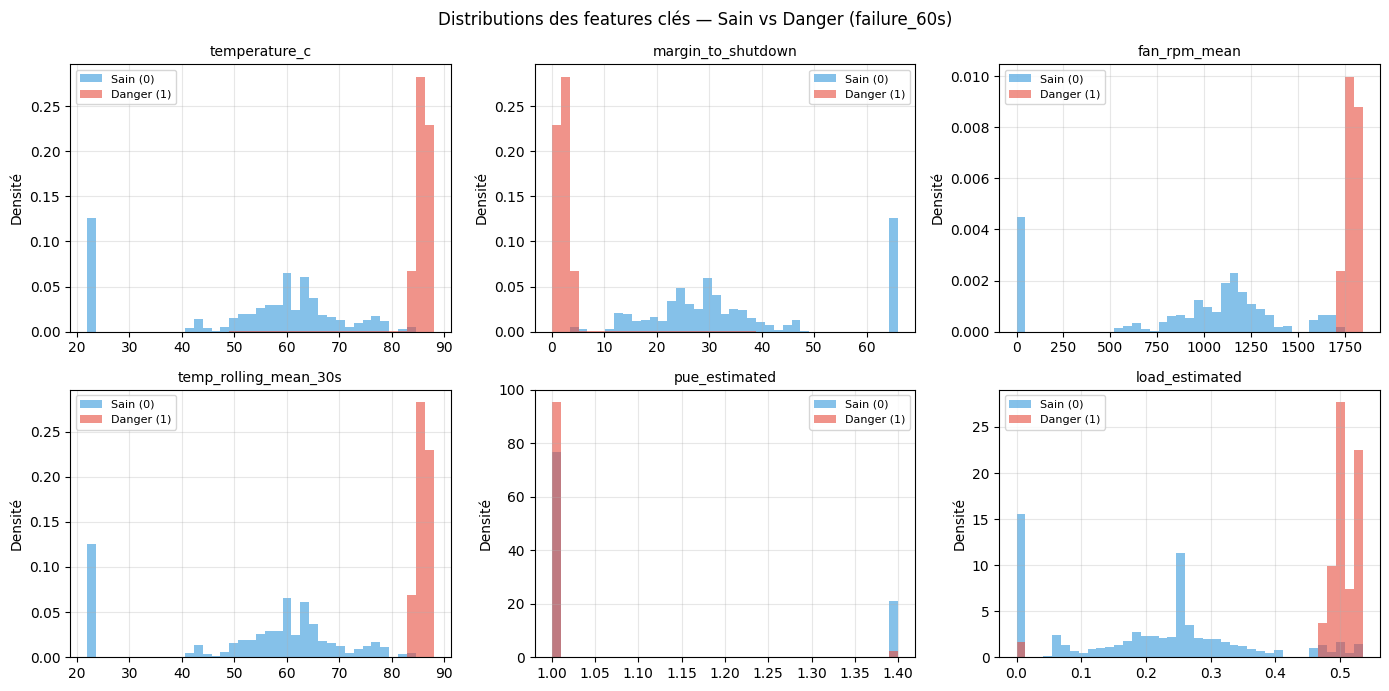

In [7]:
key_features = [
    'temperature_c', 'margin_to_shutdown', 'fan_rpm_mean',
    'temp_rolling_mean_30s', 'pue_estimated', 'load_estimated'
]
key_features = [f for f in key_features if f in X_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes_flat = axes.flatten()

for ax, feat in zip(axes_flat, key_features):
    vals_safe = X_train.loc[y_train == 0, feat].dropna()
    vals_danger = X_train.loc[y_train == 1, feat].dropna()
    bins = np.linspace(
        min(vals_safe.quantile(0.01), vals_danger.quantile(0.01)),
        max(vals_safe.quantile(0.99), vals_danger.quantile(0.99)),
        40
    )
    ax.hist(vals_safe,   bins=bins, alpha=0.6, color='#3498db', label='Sain (0)',    density=True)
    ax.hist(vals_danger, bins=bins, alpha=0.6, color='#e74c3c', label='Danger (1)',  density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distributions des features clés — Sain vs Danger (failure_60s)', fontsize=12)
plt.tight_layout()
plt.savefig('evaluation/results/fig_02_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Observations et conclusions

### Structure des features

Le dataset processed contient deux familles de labels :

- **Labels de classification** (`failure_30s`, `failure_60s`, `hot_30s`) — utilisés par le prédicteur de pannes (notebooks 03-04)
- **Labels de contrôle** (`action_class`, `action_class_v2`, `time_to_failure_s`) — utilisés pour entraîner les contrôleurs (notebook 04)

### Oracle v1 vs Oracle v2

| | Oracle v1 (`action_class`) | Oracle v2 (`action_class_v2`) |
|---|---|---|
| Score | `temperature_ratio` uniquement | `α·temp_ratio + β·temp_delta_30s + γ·urgence` |
| Hard rules | Aucune | `status=degraded`, `margin<5%`, `ttf < horizon/3` → RPM_MAX |
| RPM plancher | 0 (obsolète) | **800 RPM** (Phase 7.5) |
| Classes | 4 (0–3) | **5 (0–4)** avec classe 4 = 4500 RPM |

L'oracle v2 est plus conservateur : il peut forcer RPM_MAX même quand la température est encore
basse si une panne est imminente (`time_to_failure_s < horizon/3 = 20s`).

### `time_to_failure_s` et régimes de NaN

`time_to_failure_s` est `NaN` quand aucune panne n'est connue à l'horizon (cas nominal). La proportion
de NaN dépend du scénario : quasi-totale en `nominal`, ~30-50% en `stress`.
Cette feature est **exclue de la modélisation supervisée** (trop de NaN) mais utilisée exclusivement
par l'oracle v2 pour générer les labels d'entraînement.

### Leakage potentiel

- `pue_estimated` et `pue_rolling_mean_30s` : corrélation ~1.0 avec `failure_60s` sur certains épisodes → **data leakage** probable (le PUE intègre l'état de charge qui prédit la panne)
- `margin_to_shutdown` : feature la plus interprétable et sans leakage — distance directe au seuil
- Les rolling means thermiques (30s, 60s) sont de bons prédicteurs de tendance sans leakage

### Split temporel

Stratégie Option A : couper chaque épisode chronologiquement (70/15/15 %), puis concaténer.
Garantit que tous les scénarios sont représentés dans train/val/test sans fuite temporelle intra-épisode.

→ **Voir notebook 03** pour la modélisation de prédiction de pannes (Phase 4).  
→ **Voir notebook 04** pour l'entraînement des contrôleurs (oracle v1 vs v2).
